# Clase 5 - Aprendizaje Supervisado: K-NN y Arbol de Decision

**Dataset:** `genz_social_media_usage_1M.csv`  
**Tema:** Uso de redes sociales en la Generacion Z  
**Objetivo:** comparar dos modelos de clasificacion supervisada: **K-Nearest Neighbors** y **Arbol de Decision**.

En este trabajo se busca predecir el nivel de adiccion a redes sociales (`addiction_level`), que puede tomar los valores **Low**, **Medium** o **High**. Para eso se utilizan variables relacionadas con edad, genero, pais, plataforma principal, cantidad de plataformas usadas, proposito de uso, uso nocturno, salud mental y tiempo de pantalla antes de dormir.


Primero importamos las librerias necesarias.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Configuracion simple para ver mas columnas
pd.set_option('display.max_columns', None)

2. Lectura del dataset

In [ ]:

datos = pd.read_csv('genz_social_media_usage_1M.csv')
datos.head()

,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
0,19,Male,Australia,2.658617,Snapchat,4,Education,29.222443,0,6.705830,Medium,15.779443
1,16,Female,USA,5.685387,Twitter,3,Socializing,32.464726,1,6.633111,High,47.714864
2,25,Female,India,2.782420,TikTok,2,Socializing,18.170204,1,6.035397,Medium,62.524625
3,27,Male,India,3.486598,YouTube,4,Education,22.493804,1,8.110861,Medium,31.935102
4,23,Female,India,3.748829,TikTok,1,Entertainment,27.358410,1,6.658598,Medium,29.466046


In [3]:
print('Cantidad de filas y columnas:', datos.shape)
print('\nColumnas del dataset:')
print(datos.columns.tolist())

Cantidad de filas y columnas: (1000000, 12)

Columnas del dataset:
['age', 'gender', 'country', 'daily_usage_hours', 'primary_platform', 'num_platforms_used', 'purpose', 'avg_session_minutes', 'night_usage', 'mental_health_score', 'addiction_level', 'screen_time_before_sleep']


3. Exploracion inicial

In [4]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   age                       1000000 non-null  int64  
 1   gender                    1000000 non-null  object 
 2   country                   1000000 non-null  object 
 3   daily_usage_hours         1000000 non-null  float64
 4   primary_platform          1000000 non-null  object 
 5   num_platforms_used        1000000 non-null  int64  
 6   purpose                   1000000 non-null  object 
 7   avg_session_minutes       1000000 non-null  float64
 8   night_usage               1000000 non-null  int64  
 9   mental_health_score       1000000 non-null  float64
 10  addiction_level           1000000 non-null  object 
 11  screen_time_before_sleep  1000000 non-null  float64
dtypes: float64(4), int64(3), object(5)
memory usage: 91.6+ MB


In [ ]:

print('Valores faltantes por columna:')
print(datos.isna().sum())

Valores faltantes por columna:


age                         0
gender                      0
country                     0
daily_usage_hours           0
primary_platform            0
num_platforms_used          0
purpose                     0
avg_session_minutes         0
night_usage                 0
mental_health_score         0
addiction_level             0
screen_time_before_sleep    0
dtype: int64


In [ ]:

datos.describe()

,age,daily_usage_hours,num_platforms_used,avg_session_minutes,night_usage,mental_health_score,screen_time_before_sleep
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,19.994629,3.514998,2.999469,25.088819,0.599958,7.170671,40.120754
std,4.322119,1.468771,1.414598,9.794249,0.489907,1.503885,19.569847
min,13.000000,0.500000,1.000000,5.000000,0.000000,1.000000,0.000000
25%,16.000000,2.493985,2.000000,18.257267,0.000000,6.147371,26.459592
50%,20.000000,3.503302,3.000000,25.002480,1.000000,7.198098,39.977162
75%,24.000000,4.513016,4.000000,31.759257,1.000000,8.243818,53.424345
max,27.000000,10.000000,5.000000,80.262224,1.000000,10.000000,137.998719


In [7]:
# Distribucion de la variable objetivo
print('Distribucion de addiction_level:')
print(datos['addiction_level'].value_counts())

print('\nDistribucion porcentual:')
print(round(datos['addiction_level'].value_counts(normalize=True) * 100, 2))

Distribucion de addiction_level:
addiction_level
Medium    589843
Low       251220
High      158937
Name: count, dtype: int64

Distribucion porcentual:
addiction_level
Medium    58.98
Low       25.12
High      15.89
Name: proportion, dtype: float64


4. Definicion de la tarea de clasificacion

La variable que se quiere predecir es `addiction_level`. Es una variable categorica con tres clases:

- Low: nivel bajo de adiccion
- Medium: nivel medio de adiccion
- High: nivel alto de adiccion

Para que el ejercicio no quede demasiado obvio, no se usa `daily_usage_hours` como variable predictora, porque en este dataset esa variable esta demasiado relacionada con el nivel de adiccion. De esta forma, los modelos tienen que intentar clasificar usando otras variables del comportamiento digital.

In [8]:
# Para que K-NN no tarde demasiado, usamos una muestra aleatoria.
# Esto es util porque el dataset original tiene 1.000.000 de registros.
n_muestra = min(20000, len(datos))
datos_modelo = datos.sample(n=n_muestra, random_state=42)

print('Filas usadas para el modelo:', datos_modelo.shape[0])

Filas usadas para el modelo: 20000


In [ ]:
# Variable objetivo
y = datos_modelo['addiction_level']

# Variables predictoras
# Quitamos addiction_level porque es lo que queremos predecir.
# Tambien quitamos daily_usage_hours 
X = datos_modelo.drop(columns=['addiction_level', 'daily_usage_hours'])

print('Columnas usadas como entrada para el modelo:')
print(X.columns.tolist())

Columnas usadas como entrada para el modelo:
['age', 'gender', 'country', 'primary_platform', 'num_platforms_used', 'purpose', 'avg_session_minutes', 'night_usage', 'mental_health_score', 'screen_time_before_sleep']


In [ ]:

columnas_numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
columnas_categoricas = X.select_dtypes(include=['object']).columns.tolist()

print('Columnas numericas:', columnas_numericas)
print('Columnas categoricas:', columnas_categoricas)

Columnas numericas: ['age', 'num_platforms_used', 'avg_session_minutes', 'night_usage', 'mental_health_score', 'screen_time_before_sleep']
Columnas categoricas: ['gender', 'country', 'primary_platform', 'purpose']


5. Separacion en entrenamiento y prueba

Se divide el dataset en datos de entrenamiento y datos de prueba. Se usa `stratify=y` para mantener una proporcion similar de clases en ambos conjuntos.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Tamaño de X_train:', X_train.shape)
print('Tamaño de X_test:', X_test.shape)
print('Tamaño de y_train:', y_train.shape)
print('Tamaño de y_test:', y_test.shape)

Tamaño de X_train: (16000, 10)
Tamaño de X_test: (4000, 10)
Tamaño de y_train: (16000,)
Tamaño de y_test: (4000,)


6. Preprocesamiento de datos

In [12]:
preprocesamiento = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), columnas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), columnas_categoricas)
    ],
    verbose_feature_names_out=False
)

7. Modelo 1: K-Nearest Neighbors

K-NN clasifica cada registro segun la clase mayoritaria de sus vecinos mas cercanos. En este caso se utiliza `n_neighbors=5`.

In [13]:
modelo_knn = Pipeline(steps=[
    ('preprocesamiento', preprocesamiento),
    ('modelo', KNeighborsClassifier(n_neighbors=5))
])

modelo_knn.fit(X_train, y_train)

pred_knn = modelo_knn.predict(X_test)

accuracy_knn = accuracy_score(y_test, pred_knn)
print('Accuracy K-NN:', round(accuracy_knn, 4))
print('\nReporte de clasificacion K-NN:')
print(classification_report(y_test, pred_knn))

Accuracy K-NN: 0.6105

Reporte de clasificacion K-NN:
              precision    recall  f1-score   support

        High       0.46      0.30      0.36       639
         Low       0.56      0.45      0.50      1021
      Medium       0.65      0.76      0.70      2340

    accuracy                           0.61      4000
   macro avg       0.56      0.51      0.52      4000
weighted avg       0.60      0.61      0.60      4000



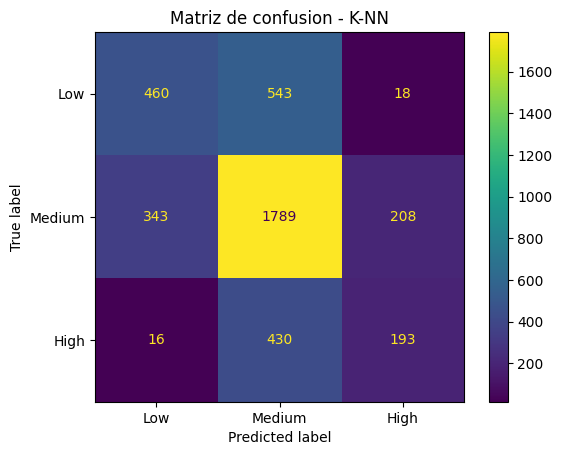

In [14]:
# Matriz de confusion para K-NN
labels = ['Low', 'Medium', 'High']
cm_knn = confusion_matrix(y_test, pred_knn, labels=labels)

ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=labels).plot()
plt.title('Matriz de confusion - K-NN')
plt.show()

8. Modelo 2: Arbol de Decision

In [15]:
modelo_arbol = Pipeline(steps=[
    ('preprocesamiento', preprocesamiento),
    ('modelo', DecisionTreeClassifier(max_depth=5, random_state=42))
])

modelo_arbol.fit(X_train, y_train)

pred_arbol = modelo_arbol.predict(X_test)

accuracy_arbol = accuracy_score(y_test, pred_arbol)
print('Accuracy Arbol de Decision:', round(accuracy_arbol, 4))
print('\nReporte de clasificacion Arbol de Decision:')
print(classification_report(y_test, pred_arbol))

Accuracy Arbol de Decision: 0.7045

Reporte de clasificacion Arbol de Decision:
              precision    recall  f1-score   support

        High       0.66      0.41      0.50       639
         Low       0.73      0.54      0.62      1021
      Medium       0.70      0.86      0.77      2340

    accuracy                           0.70      4000
   macro avg       0.70      0.60      0.63      4000
weighted avg       0.70      0.70      0.69      4000



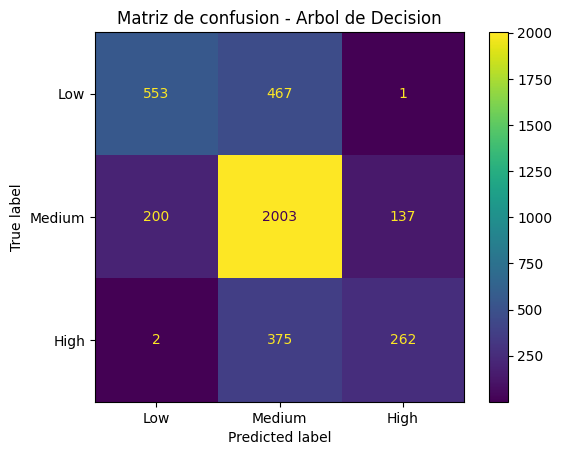

In [16]:
# Matriz de confusion para Arbol de Decision
cm_arbol = confusion_matrix(y_test, pred_arbol, labels=labels)

ConfusionMatrixDisplay(confusion_matrix=cm_arbol, display_labels=labels).plot()
plt.title('Matriz de confusion - Arbol de Decision')
plt.show()

## 9. Comparacion de modelos

Ahora se comparan los valores de precision general (`accuracy`) obtenidos por ambos clasificadores.

In [17]:
comparacion = pd.DataFrame({
    'Modelo': ['K-NN', 'Arbol de Decision'],
    'Accuracy': [accuracy_knn, accuracy_arbol]
})

comparacion

,Modelo,Accuracy
0,K-NN,0.6105
1,Arbol de Decision,0.7045


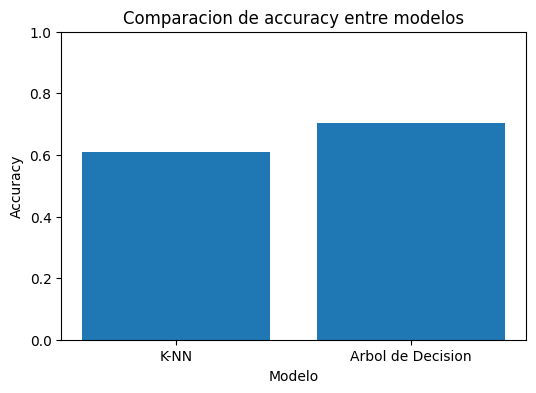

In [18]:
plt.figure(figsize=(6, 4))
plt.bar(comparacion['Modelo'], comparacion['Accuracy'])
plt.ylim(0, 1)
plt.title('Comparacion de accuracy entre modelos')
plt.xlabel('Modelo')
plt.ylabel('Accuracy')
plt.show()

10. Una ventaja del Arbol de Decision es que permite analizar que variables fueron mas importantes para clasificar los datos.

In [19]:
# Obtener nombres de variables luego del preprocesamiento
nombres_variables = modelo_arbol.named_steps['preprocesamiento'].get_feature_names_out()
importancias = modelo_arbol.named_steps['modelo'].feature_importances_

importancia_df = pd.DataFrame({
    'variable': nombres_variables,
    'importancia': importancias
}).sort_values(by='importancia', ascending=False)

importancia_df.head(10)

,variable,importancia
4,mental_health_score,0.986225
5,screen_time_before_sleep,0.006079
2,avg_session_minutes,0.004423
0,age,0.001904
18,primary_platform_TikTok,0.001369
1,num_platforms_used,0.000000
6,gender_Female,0.000000
7,gender_Male,0.000000
8,gender_Other,0.000000
3,night_usage,0.000000


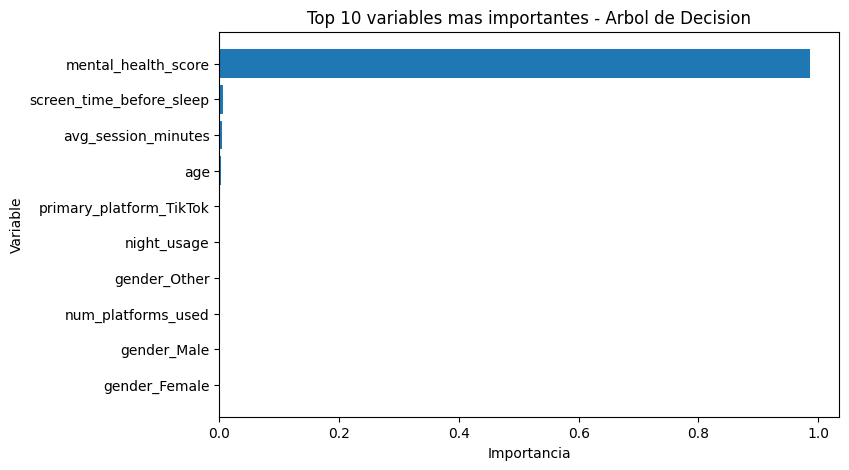

In [20]:
top_importancias = importancia_df.head(10).sort_values(by='importancia')

plt.figure(figsize=(8, 5))
plt.barh(top_importancias['variable'], top_importancias['importancia'])
plt.title('Top 10 variables mas importantes - Arbol de Decision')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.show()

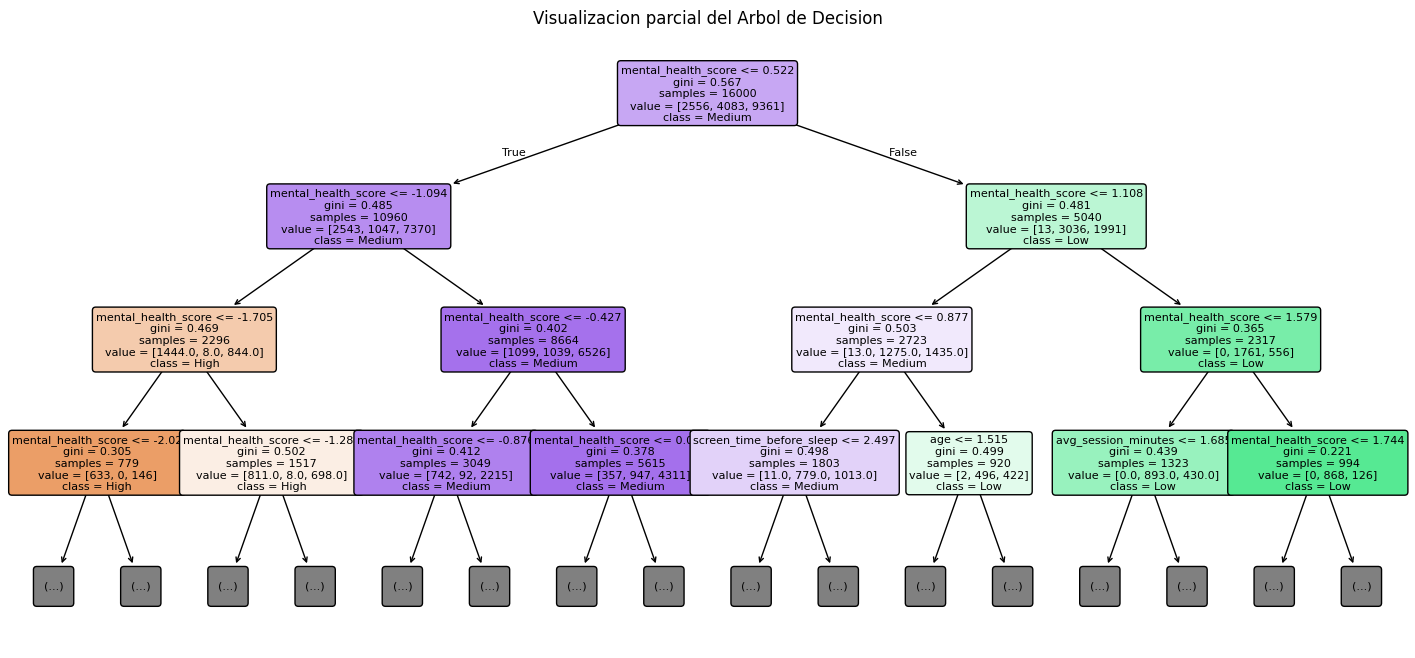

In [ ]:

plt.figure(figsize=(18, 8))
plot_tree(
    modelo_arbol.named_steps['modelo'],
    feature_names=nombres_variables,
    class_names=modelo_arbol.named_steps['modelo'].classes_,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title('Visualizacion parcial del Arbol de Decision')
plt.show()


En este trabajo se aplicaron dos algoritmos de aprendizaje supervisado vistos en la clase: K-Nearest Neighbors y Arbol de Decision. El objetivo fue predecir el nivel de adiccion a redes sociales en usuarios de la Generacion Z.

Al comparar los resultados, el Arbol de Decision obtuvo una precision mayor que K-NN. Esto puede deberse a que el arbol logra generar reglas de decision mas claras a partir de las variables disponibles, mientras que K-NN depende mucho de las distancias entre registros y puede verse afectado por la cantidad de variables y por la mezcla entre datos numericos y categoricos.

Tambien se observo que algunas variables, especialmente el puntaje de salud mental, tuvieron mucha importancia para el Arbol de Decision. Esto muestra que el dataset permite analizar posibles relaciones entre habitos digitales, bienestar personal y nivel de adiccion.

Como conclusion general, para este caso el Arbol de Decision fue el modelo con mejor resultado, ademas de ser mas facil de interpretar visualmente. De todas formas, K-NN tambien fue util como comparacion porque permite entender otro enfoque de clasificacion basado en vecinos cercanos.